### Algorytm S3VM

Głównym celem S3VM jest minimalizacja następującej funkcji celu:

$$\min_{\mathbf{w}, b, \mathbf{\eta}, \mathbf{\xi}, \mathbf{z}} \left[ \|\mathbf{w}\| + C \left( \sum_{i=1}^{N} \eta_i + \sum_{j=N+1}^{N+M} \min(\xi_j, z_j) \right) \right]$$

gdzie

- $\|\mathbf{w}\|$ — norma $L_2$ wektora wag.  
- $C$ — hiperparametr kontrolujący kompromis między maksymalizacją marginesu a minimalizacją błędów klasyfikacji.  
- $\sum_{i=1}^{N} \eta_i$ — suma kar (zmiennych swobodnych $\eta_i$) dla $N$ próbek etykietowanych.  
- $\sum_{j=N+1}^{N+M} \min(\xi_j, z_j)$ — suma kar dla $M$ próbek nieetykietowanych.


### Ograniczenia
Minimalizacja funkcji celu odbywa się przy następujących ograniczeniach:

$$y_i(\mathbf{w}^T \mathbf{x}_i + b) \ge 1 - \eta_i \quad \text{oraz} \quad \eta_i \ge 0$$

- Dla próbek nieetykietowanych ($j=N+1, \dots, N+M$), zakładając klasę +1:
$$ (\mathbf{w}^T \mathbf{x}_j - b) \ge 1 - \xi_j \quad \text{oraz} \quad \xi_j \ge 0 $$
- Dla próbek nieetykietowanych ($j=N+1, \dots, N+M$), zakładając klasę -1:
$$-(\mathbf{w}^T \mathbf{x}_j - b) \ge 1 - z_j \quad \text{oraz} \quad z_j \ge 0 $$

# Przygotowanie Danych

In [1]:
from sklearn.datasets import make_classification

nb_samples = 100
nb_unlabeled = 50
X, Y = make_classification(n_samples=nb_samples, n_features=2, n_redundant=0, random_state=1000)
Y[Y==0] = -1
Y[nb_samples - nb_unlabeled:nb_samples] = 0

Inicjalizacja Zmiennych Optymalizacyjnych

In [2]:
import numpy as np

w = np.random.uniform(-0.1, 0.1, size=X.shape[1])
eta = np.random.uniform(0.0, 0.1, size=nb_samples - nb_unlabeled)
xi = np.random.uniform(0.0, 0.1, size=nb_unlabeled)
zi = np.random.uniform(0.0, 0.1, size=nb_unlabeled)
b = np.random.uniform(-0.1, 0.1, size=1)
C = 1.0
theta0 = np.hstack((w, eta, xi, zi, b))

Funkcja Celu

In [3]:
vmin = np.vectorize(lambda x1, x2: x1 if x1 <= x2 else x2)

def svm_target(theta, Xd, Yd):
  wt = theta[0:2].reshape((Xd.shape[1], 1))
  
  s_eta = np.sum(theta[2:2 + nb_samples - nb_unlabeled])
  s_min_xi_zi = np.sum(vmin(theta[2 + nb_samples - nb_unlabeled:2 + nb_samples], 
                        theta[2 + nb_samples:2 + nb_samples + nb_unlabeled]))
  return C * (s_eta + s_min_xi_zi) + 0.5 * np.dot(wt.T, wt)

Funkcje Ograniczeń (Constraints)

Te funkcje definiują warunki, które muszą być spełnione podczas optymalizacji. Każda funkcja musi zwracać wartość $\ge 0$, aby ograniczenie było spełnione.

In [4]:
def labeled_constraint(theta, Xd, Yd, idx):
  wt = theta[0:2].reshape((Xd.shape[1], 1))
  
  c = Yd[idx] * (np.dot(Xd[idx], wt) + theta[-1]) + theta[2:2 + nb_samples - nb_unlabeled][idx] - 1.0
  
  return (c >= 0)[0]

In [5]:
def unlabeled_constraint_1(theta, Xd, idx):
  wt = theta[0:2].reshape((Xd.shape[1], 1))
  
  c = np.dot(Xd[idx], wt) - theta[-1] + theta[2 + nb_samples - nb_unlabeled:2 + nb_samples][idx - nb_samples + nb_unlabeled] - 1.0
  
  return (c >= 0)[0]

In [6]:
def unlabeled_constraint_2(theta, Xd, idx):
  wt = theta[0:2].reshape((Xd.shape[1], 1))
  
  c = -(np.dot(Xd[idx], wt) - theta[-1]) + theta[2 + nb_samples:2 + nb_samples + nb_unlabeled ][idx - nb_samples + nb_unlabeled] - 1.0
  
  return (c >= 0)[0]

In [7]:
def eta_constraint(theta, idx):
  return theta[2:2 + nb_samples - nb_unlabeled][idx] >= 0
def xi_constraint(theta, idx):
  return theta[2 + nb_samples - nb_unlabeled:2 + nb_samples][idx - 
 nb_samples + nb_unlabeled] >= 0
def zi_constraint(theta, idx):
  return theta[2 + nb_samples:2 + nb_samples+nb_unlabeled ][idx - 
 nb_samples + nb_unlabeled] >= 0

Przygotowanie i Wywołanie Optymalizatora

In [8]:
svm_constraints = []

# Ograniczenia dla próbek etykietowanych
for i in range(nb_samples - nb_unlabeled):
    svm_constraints.append({
        'type': 'ineq',
        'fun': labeled_constraint,
        'args': (X, Y, i)
    })
    svm_constraints.append({
        'type': 'ineq',
        'fun': eta_constraint,
        'args': (i,)
    })

# Ograniczenia dla próbek nieetykietowanych
for i in range(nb_samples - nb_unlabeled, nb_samples):
    svm_constraints.append({
        'type': 'ineq',
        'fun': unlabeled_constraint_1,
        'args': (X, i)
    })
    svm_constraints.append({
        'type': 'ineq',
        'fun': unlabeled_constraint_2,
        'args': (X, i)
    })
    svm_constraints.append({
        'type': 'ineq',
        'fun': xi_constraint,
        'args': (i,)
    })
    svm_constraints.append({
        'type': 'ineq',
        'fun': zi_constraint,
        'args': (i,)
    })

In [ ]:
from scipy.optimize import minimize
result = minimize(fun=svm_target, 
  x0=theta0, 
  constraints=svm_constraints, 
  args=(X, Y), 
  method='COBYLA', 
  tol=0.0001, 
  options={'maxiter': 5000})

Po zakończeniu procesu uczenia możemy obliczyć etykiety dla punktów nieetykietowanych.

In [ ]:
theta_end = result['x']
w = theta_end[0:2]
b = theta_end[-1]
Xu= X[nb_samples - nb_unlabeled:nb_samples]
yu = -np.sign(np.dot(Xu, w) + b)

### Wizualizacja wyników 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Podział danych na grupy do rysowania
X_labeled_0 = X[Y == -1]
X_labeled_1 = X[Y == 1]
X_unlabeled_orig = X[Y == 0] # Oryginalne nieetykietowane

# Podział danych nieetykietowanych na podstawie predykcji
Xu_predicted_0 = Xu[yu == -1]
Xu_predicted_1 = Xu[yu == 1]

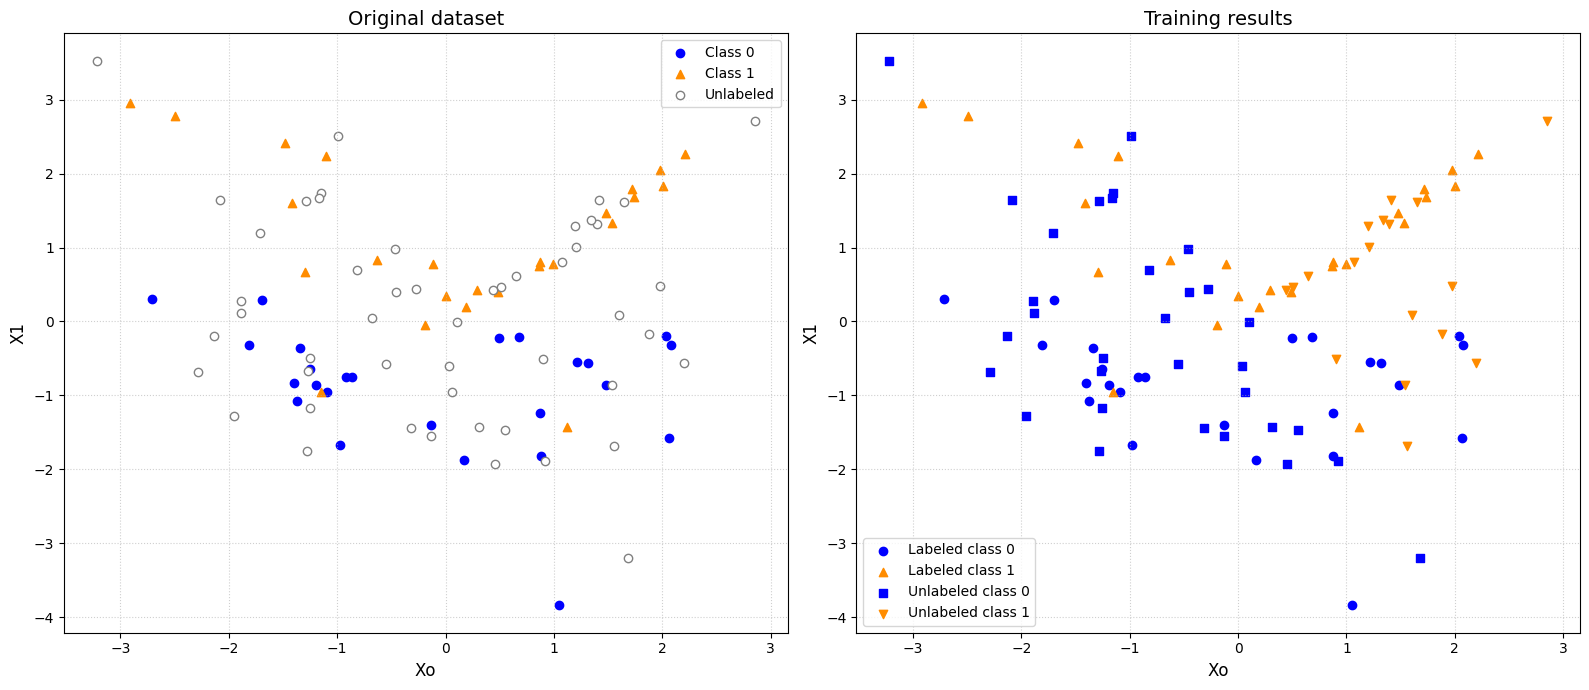

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

ax[0].scatter(X_labeled_0[:, 0], X_labeled_0[:, 1], c='blue', marker='o', label='Class 0')
ax[0].scatter(X_labeled_1[:, 0], X_labeled_1[:, 1], c='darkorange', marker='^', label='Class 1')
ax[0].scatter(X_unlabeled_orig[:, 0], X_unlabeled_orig[:, 1], c='white', marker='o', edgecolors='gray', label='Unlabeled')
ax[0].set_title('Original dataset', fontsize=14)
ax[0].set_xlabel('Xo', fontsize=12)
ax[0].set_ylabel('X1', fontsize=12)
ax[0].legend()
ax[0].grid(True, linestyle=':', alpha=0.6)


ax[1].scatter(X_labeled_0[:, 0], X_labeled_0[:, 1], c='blue', marker='o', label='Labeled class 0')
ax[1].scatter(X_labeled_1[:, 0], X_labeled_1[:, 1], c='darkorange', marker='^', label='Labeled class 1')
ax[1].scatter(Xu_predicted_0[:, 0], Xu_predicted_0[:, 1], c='blue', marker='s', label='Unlabeled class 0')
ax[1].scatter(Xu_predicted_1[:, 0], Xu_predicted_1[:, 1], c='darkorange', marker='v', label='Unlabeled class 1')
ax[1].set_title('Training results', fontsize=14)
ax[1].set_xlabel('Xo', fontsize=12)
ax[1].set_ylabel('X1', fontsize=12)
ax[1].legend()
ax[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()

## Zadania ćwiczeniowe — S3VM (do wykonania po uruchomieniu)
Poniżej znajdują się proste zadania do wykonania podczas zajęć. Każde zadanie zawiera miejsca oznaczone jako # TODO — uzupełnijcie je kodem.

In [ ]:
# Zadanie 1: Eksperyment z hiperparametrem C
# Cel: zobaczyć jak zmiana C wpływa na decyzję i etykiety nieetykietowanych punktów.
# Wskazówka: funkcja 'svm_target' używa zmiennej globalnej C — zmień ją i ponownie uruchom optymalizator.
C_values = [0.01, 0.1, 1.0, 10.0]
results_by_C = {}
for C_test in C_values:
    # TODO: ustaw globalną zmienną C = C_test
    # TODO: skopiuj i zaadaptuj wywołanie 'minimize' z komórki optymalizatora wyżej (zapewnij, że theta0 i constraints są dostępne lub zainicjalizuj ponownie)
    # TODO: zapisz wynik i przypisane etykiety dla Xu w results_by_C[C_test]
    pass

# TODO: po wykonaniu zaimplementuj krótkie podsumowanie np. liczba punktów przydzielonych do każdej klasy dla różnych C
# Przykład wyświetlenia: print(C_test, np.bincount(yu_pred_adjusted + 1))  # jeśli klasy w {-1,1}

In [ ]:
# Zadanie 2: Zmiana liczby punktów nieetykietowanych
# Cel: sprawdź jak liczba punktów bez etykiet wpływa na model.
# TODO: ustaw nową wartość nb_unlabeled (np. 10, 30, 70), wygeneruj dane ponownie i zainicjalizuj theta0.
# Uwaga: pamiętaj o ponownym przygotowaniu svm_constraints (indeksacja zależy od nb_unlabeled), a następnie wywołaniu minimize.
# Szkic rozwiązania:
# nb_unlabeled = 30
# nb_samples = 100
# X, Y = make_classification(n_samples=nb_samples, n_features=2, n_redundant=0, random_state=1000)
# Y[Y==0] = -1
# Y[nb_samples - nb_unlabeled:nb_samples] = 0
# TODO: zainicjalizuj w, eta, xi, zi, b, theta0 i constraints -> minimize
pass

In [ ]:
# Zadanie 3: Narysuj granicę decyzyjną (decision boundary)
# Cel: dorysować kontur funkcji decyzyjnej w drugim wykresie i zobaczyć, gdzie leżą nieetykietowane punkty.
# TODO: uzupełnij poniższy kod - oblicz wartości decyzyjne na siatce i narysuj contourf/contour
xx_min, xx_max = X[:,0].min() - 1, X[:,0].max() + 1
yy_min, yy_max = X[:,1].min() - 1, X[:,1].max() + 1
xx, yy = np.meshgrid(np.linspace(xx_min, xx_max, 200), np.linspace(yy_min, yy_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
# TODO: oblicz Z = decision value dla każdego punktu na grid (użyj w i b) i zrób reshape
# Przykład: Z = np.dot(grid, w) + b; Z = Z.reshape(xx.shape)
# plt.figure(figsize=(6,6)); plt.contourf(xx, yy, np.sign(Z), alpha=0.2, levels=[-1,0,1])
# Dorysuj punkty: labeled i unlabeled (tak jak w poprzednim wykresie)
pass

In [ ]:
# Zadanie 4: Punkty bliskie granicy (analiza marginesu)
# Cel: znaleźć nieetykietowane punkty najbliżej granicy decyzyjnej — mogą to być trudne przypadki.
# TODO: uzupełnij kod poniżej - policz odległość punktów Xu od hiperplanu i wypisz top 5 najbliższych.
# Przykładowy szkic rozwiązania:
# margins = np.abs(np.dot(Xu, w) + b) / np.linalg.norm(w)
# idx_sorted = np.argsort(margins)
# print('5 punktów najbliższych granicy:')
# print(Xu[idx_sorted[:5]])
pass